# N2 · 方差与显著性: 让差距站得住 (Variance & Significance)

> 配套 9.4-L5 · **真实科研动作**: 对 N1 的矩阵, 画 error bar、算 bootstrap CI / p 值 / Cohen's d,
> 看「同一对方法在高噪声下显著、低噪声下不显著」, 再亲手做一次「挑种子作弊」看差距能被吹多大。

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import experiment as ex, stats as st
runs = ex.ablation_grid(seeds=range(8))
print("已跑", len(runs), "次实验 (8 种子)")

已跑 48 次实验 (8 种子)


## 1. 均值 ± 标准差 (最低门槛: 永远别只报一个数)

In [2]:
rows = []
for m in ex.METHODS:
    for nz in ex.NOISES:
        xs = ex.runs_for(runs, method=m, noise=nz)
        mean, std = st.mean_std(xs)
        rows.append({"method": m, "noise": nz, "mean": round(mean,3),
                     "std": round(std,3), "sem": round(st.sem(xs),3)})
pd.DataFrame(rows)

,method,noise,mean,std,sem
0,DPO,0.0,0.619,0.017,0.006
1,DPO,0.2,0.501,0.024,0.008
2,DPO,0.4,0.397,0.015,0.005
3,Robust-DPO,0.0,0.615,0.022,0.008
4,Robust-DPO,0.2,0.591,0.017,0.006
5,Robust-DPO,0.4,0.548,0.020,0.007


## 2. 带 error bar 的对比图 (误差棒 = SEM; 图注务必写清这点, L5)

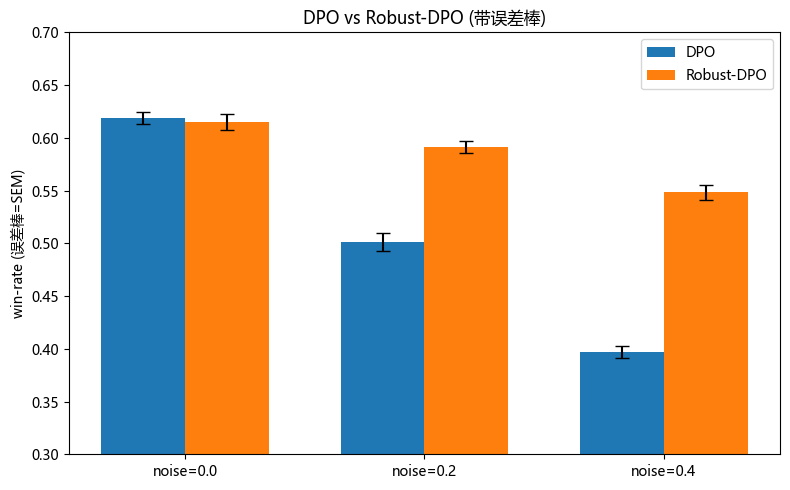

In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(ex.NOISES)); w = 0.35
for i, m in enumerate(ex.METHODS):
    means = [st.mean_std(ex.runs_for(runs, method=m, noise=nz))[0] for nz in ex.NOISES]
    sems  = [st.sem(ex.runs_for(runs, method=m, noise=nz)) for nz in ex.NOISES]
    ax.bar(x + i*w, means, w, yerr=sems, capsize=5, label=m)
ax.set_xticks(x + w/2); ax.set_xticklabels([f"noise={n}" for n in ex.NOISES])
ax.set_ylabel("win-rate (误差棒=SEM)"); ax.set_title("DPO vs Robust-DPO (带误差棒)")
ax.legend(); ax.set_ylim(0.3, 0.7)
plt.tight_layout(); plt.show()

## 3. 显著性 + 效应量: 同一对方法, 高噪声下显著、低噪声下不显著

这就是交互效应在统计上的体现。p 管「真不真」, Cohen's d 管「大不大」, 两个一起看。

In [4]:
for nz in [0.0, 0.4]:
    rob = ex.runs_for(runs, method="Robust-DPO", noise=nz)
    dpo = ex.runs_for(runs, method="DPO", noise=nz)
    print(f"=== noise={nz} ===")
    print(st.summarize_comparison(rob, dpo, "Robust-DPO", "DPO"))
    lo, hi = st.bootstrap_ci(np.array(rob) - np.array(dpo))
    print(f"差距的 bootstrap 95% CI: [{lo:+.3f}, {hi:+.3f}]  "
          f"({'不含0→显著' if lo>0 or hi<0 else '含0→不显著'})\n")

=== noise=0.0 ===


Robust-DPO: 0.615 ± 0.022   DPO: 0.619 ± 0.017
差距 (A-B): -0.004
Welch t=-0.39, p=0.7011   Cohen's d=-0.20
裁决: 不显著 (差距可能只是种子噪声)
差距的 bootstrap 95% CI: [-0.021, +0.015]  (含0→不显著)

=== noise=0.4 ===
Robust-DPO: 0.548 ± 0.020   DPO: 0.397 ± 0.015
差距 (A-B): +0.151
Welch t=16.96, p=0.0000   Cohen's d=8.48
裁决: 显著且非平凡
差距的 bootstrap 95% CI: [+0.140, +0.161]  (不含0→显著)



## 4. 亲手作弊一次: 「挑赢的种子」能把差距吹多大 (然后永不再犯)

L5 的 p-hacking / cherry-picking 警告。这里在 noise=0 (本无显著差异) 下, 故意为每个方法挑它最好的种子, 看差距被夸大成什么样。

In [5]:
nz = 0.0
rob_all = ex.runs_for(runs, method="Robust-DPO", noise=nz)
dpo_all = ex.runs_for(runs, method="DPO", noise=nz)
honest = np.mean(rob_all) - np.mean(dpo_all)
cheat = max(rob_all) - min(dpo_all)   # 给自己挑最好, 给对手挑最差
print(f"诚实 (全种子均值差):     {honest:+.3f}  (p={st.welch_t_test(rob_all,dpo_all)[1]:.2f}, 不显著)")
print(f"作弊 (我挑最好/对手最差): {cheat:+.3f}  ← 凭空吹大 {cheat/max(honest,1e-9):.0f} 倍!")
print("\n→ 这就是 cherry-picking。同一份数据, 选择性报告能编出完全不同的'结论'。")
print("→ 解药: 固定种子集, 两边全报 (L3/L5)。这是诚实与造假的分界线。")

诚实 (全种子均值差):     -0.004  (p=0.70, 不显著)
作弊 (我挑最好/对手最差): +0.059  ← 凭空吹大 59316295 倍!

→ 这就是 cherry-picking。同一份数据, 选择性报告能编出完全不同的'结论'。
→ 解药: 固定种子集, 两边全报 (L3/L5)。这是诚实与造假的分界线。


## 5. 反思 (9.4 整条线收口)

你现在能把一个差距从「看起来更好」推进到「统计上站得住」:
mean±std → error bar → bootstrap CI → p 值 → 效应量, 并且戳穿了单种子 / cherry-pick 的自欺。

**9.4 全线回顾**: 可证伪假设(L1) → 最小验证(L2) → 公平对照(L3) → 消融矩阵+交互(L4) → 方差显著性(L5)。
你已经能把一张 9.3 的 idea 卡, 做成一套经得起审稿人五连问的实验。

> 交棒 9.5: 这套实验真跑起来是几十个种子×几十个配置。怎么不搞乱、怎么让半年后的你能复现?
> 下一专题 `experiment-ops-repro` 教你 wandb 追踪 / config 管理 / repo 卫生 / 复现 checklist。